# Train/Test Split Generator

This notebook generates the train/test split for the project based on protein-family holdout.

Creates files: `train_test_split.txt`, `train_receptors.csv`, `test_receptors.csv` that can be committed to git for shared reference

## 1. Configuration

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
import os

module_path = os.path.abspath('../src/utils') 


# Insert the path at the beginning of the system path
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from family_mapping import assign_family

# Path to your labeled CSV
CSV_PATH = Path("../data/processed/data_processed_v3_base_dataset_deduped.csv")

# Output directory
OUTPUT_DIR = Path("data/splits")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Version label
VERSION = "v3_deduped"

LABEL_COL = "label"

print(f"Config OK. Output will be saved to: {OUTPUT_DIR.resolve()}")

Config OK. Output will be saved to: \\wsl.localhost\Ubuntu\home\persav\git\cs229-md-prediction\notebooks\data\splits


## 2. Load Data & Assign Families

In [6]:
# Load data
df = pd.read_csv(CSV_PATH)
df["y"] = df[LABEL_COL].map({"single_state": 0, "multi_state": 1})

print(f"Loaded: {len(df)} samples")
print(f"  Single: {(df[LABEL_COL]=='single_state').sum()}")
print(f"  Multi:  {(df[LABEL_COL]=='multi_state').sum()}")

Loaded: 247 samples
  Single: 176
  Multi:  71


In [7]:
df["family"] = df["receptor"].apply(assign_family)

print(f"\nFamily assignment: {df['family'].nunique()} families")
print(f"Proteins in 'Other': {(df['family']=='Other').sum()}")
print(f"Print list of proteins in 'Other': {df[df['family']=='Other']['receptor'].tolist()}")


Family assignment: 23 families
Proteins in 'Other': 0
Print list of proteins in 'Other': []


## 3. Identify Viable Test Families

In [8]:
# Summarize by family
family_summary = (df.groupby("family")
                    .agg(
                        n_total=("receptor", "count"),
                        n_multi=("y", "sum"),
                        n_single=("receptor", lambda x: (df.loc[x.index, LABEL_COL] == "single_state").sum()),
                        n_proteins=("receptor", "nunique")
                    )
                    .reset_index())
family_summary["multi_frac"] = family_summary["n_multi"] / family_summary["n_total"]

# Viable test families: ≥1 multi_state, ≥2 total samples
viable_test = family_summary[
    (family_summary["n_multi"] >= 1) & 
    (family_summary["n_total"] >= 2)
].sort_values("n_total", ascending=False)

print("\nViable test families (≥1 multi, ≥2 total):")
print("=" * 80)
print(viable_test[["family", "n_total", "n_multi", "n_single", "n_proteins", "multi_frac"]].to_string(index=False))
print()
print("\nWant to target 2-3 families with ~20-30% of data and good multi_state representation")
print("20-30% of data is {} to {} samples in test set".format(int(len(df) * 0.2), int(len(df) * 0.3)))


Viable test families (≥1 multi, ≥2 total):
         family  n_total  n_multi  n_single  n_proteins  multi_frac
     Adrenergic       57       17        40          24    0.298246
      Adenosine       32       11        21          21    0.343750
        Peptide       20        9        11          15    0.450000
     Muscarinic       13        3        10           8    0.230769
         Opioid       13        4         9           9    0.307692
      Chemokine       12        7         5           7    0.583333
       Arrestin       11        1        10           5    0.090909
     Purinergic       10        3         7           5    0.300000
          Lipid        9        5         4           6    0.555556
         Visual        9        1         8           9    0.111111
         Orexin        7        4         3           5    0.571429
      Serotonin        5        2         3           3    0.400000
       Secretin        3        1         2           3    0.333333
Free

## 4. Generate Split

**Choose families to go in the test set based on the viable families table above, then edit the `TEST_FAMILIES` list below**

In [9]:
# ============================================================================
# EDIT THIS LINE - Choose which families go in the test set
# ============================================================================
TEST_FAMILIES = ["Peptide", "Adenosine", "Serotonin"]  
# ============================================================================

# Generate split
train_receptors = df[~df["family"].isin(TEST_FAMILIES)]["receptor"].unique()
test_receptors = df[df["family"].isin(TEST_FAMILIES)]["receptor"].unique()

train_df = df[df["receptor"].isin(train_receptors)]
test_df = df[df["receptor"].isin(test_receptors)]

print(f"\nTrain/Test Split Summary")
print("=" * 80)
print(f"Test families: {TEST_FAMILIES}")
print()
print(f"Train set: {len(train_df)} samples from {len(train_receptors)} proteins")
print(f"  Single: {(train_df[LABEL_COL] == 'single_state').sum()} ({(train_df[LABEL_COL] == 'single_state').sum()/len(train_df)*100:.1f}%)")
print(f"  Multi:  {(train_df[LABEL_COL] == 'multi_state').sum()} ({(train_df[LABEL_COL] == 'multi_state').sum()/len(train_df)*100:.1f}%)")
print()
print(f"Test set: {len(test_df)} samples from {len(test_receptors)} proteins")
print(f"  Single: {(test_df[LABEL_COL] == 'single_state').sum()} ({(test_df[LABEL_COL] == 'single_state').sum()/len(test_df)*100:.1f}%)")
print(f"  Multi:  {(test_df[LABEL_COL] == 'multi_state').sum()} ({(test_df[LABEL_COL] == 'multi_state').sum()/len(test_df)*100:.1f}%)")
print()
print(f"Test percentage: {len(test_df)/len(df)*100:.1f}%")


Train/Test Split Summary
Test families: ['Peptide', 'Adenosine', 'Serotonin']

Train set: 190 samples from 105 proteins
  Single: 141 (74.2%)
  Multi:  49 (25.8%)

Test set: 57 samples from 39 proteins
  Single: 35 (61.4%)
  Multi:  22 (38.6%)

Test percentage: 23.1%


## 5. Write Split File

This generates `train_test_split.txt`, `train_receptors.csv`, `test_receptors.csv`

In [46]:
split_file = OUTPUT_DIR / f"train_test_split_{VERSION}.txt"

with open(split_file, "w") as f:
    f.write("# Train/Test Split - Protein Family Holdout\n")
    f.write(f"# Generated: {VERSION}\n")
    f.write(f"# Source: {CSV_PATH.name}\n")
    f.write(f"# Total samples: {len(df)} ({len(train_df)} train, {len(test_df)} test)\n")
    f.write("\n")
    
    f.write("TEST_FAMILIES:\n")
    for fam in TEST_FAMILIES:
        fam_df = df[df["family"] == fam]
        n_multi = (fam_df[LABEL_COL]=='multi_state').sum()
        n_single = (fam_df[LABEL_COL]=='single_state').sum()
        f.write(f"  {fam}: {len(fam_df)} samples ({n_multi} multi, {n_single} single)\n")
    f.write("\n")
    
    f.write("TRAIN_FAMILIES:\n")
    train_families = sorted(train_df["family"].unique())
    for fam in train_families:
        if fam == "Other":
            continue
        fam_df = train_df[train_df["family"] == fam]
        n_multi = (fam_df[LABEL_COL]=='multi_state').sum()
        n_single = (fam_df[LABEL_COL]=='single_state').sum()
        f.write(f"  {fam}: {len(fam_df)} samples ({n_multi} multi, {n_single} single)\n")

print(f"\nSplit saved to: {split_file.resolve()}")

train_df[["receptor", "family", LABEL_COL]].to_csv(OUTPUT_DIR / f"train_receptors_{VERSION}.csv", index=False)
test_df[["receptor", "family", LABEL_COL]].to_csv(OUTPUT_DIR / f"test_receptors_{VERSION}.csv", index=False)

print(f"\nTrain and test sets saved to train_receptors_{VERSION}.csv and test_receptors_{VERSION}.csv in the splits directory")


Split saved to: \\wsl.localhost\Ubuntu\home\persav\git\cs229-md-prediction\notebooks\data\splits\train_test_split_v3_deduped.txt

Train and test sets saved to train_receptors_v3_deduped.csv and test_receptors_v3_deduped.csv in the splits directory


## 6. Visualize Split

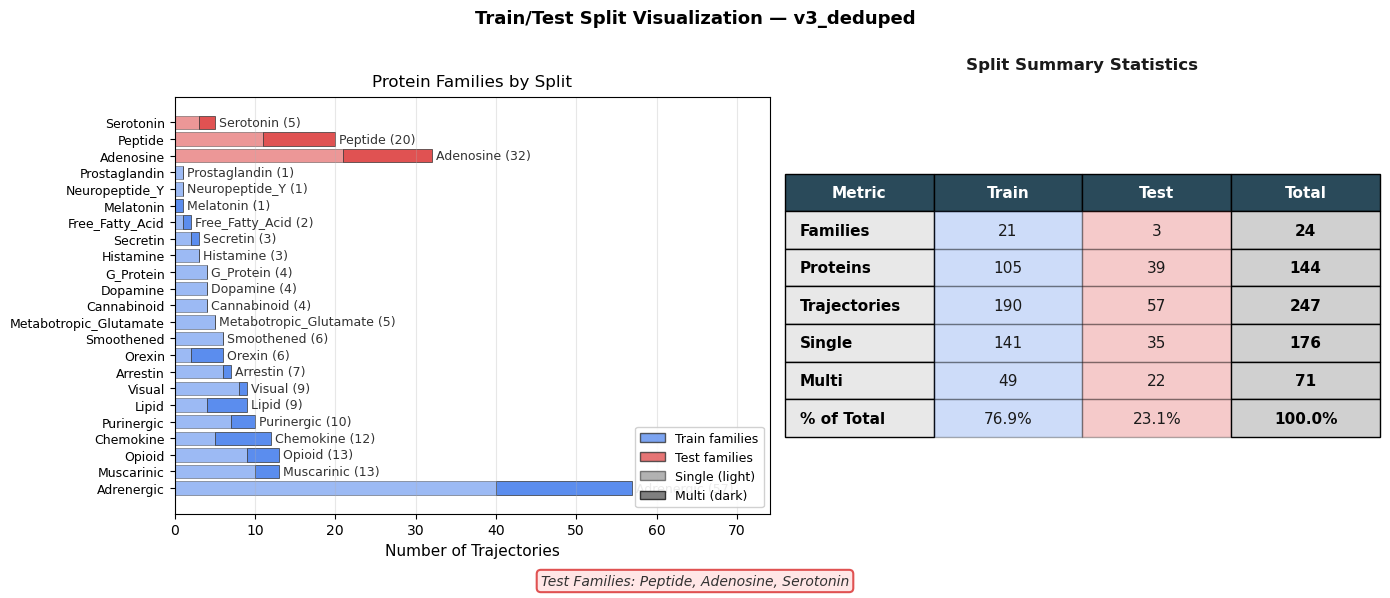


 Saved visualization: data\splits/train_test_split_viz_v3_deduped.png


In [45]:
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# Visualize Train/Test Split
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Train/Test Split Visualization — {VERSION}", fontsize=13, fontweight="bold")

# Color scheme
C_TRAIN = "#5b8dee"
C_TEST = "#e05252"
C_SINGLE = "#4a7ba7"
C_MULTI = "#d94a4a"

# ── Left: Family composition (train vs test) ─────────────────────────────────

ax = axes[0]
ax.set_facecolor("#ffffff")

# Combine train and test family summaries
all_families = []
for fam in sorted(set(df['family'].unique()) - {'Other'}):
    fam_df = df[df['family'] == fam]
    is_test = fam in TEST_FAMILIES
    n_total = len(fam_df)
    n_multi = (fam_df[LABEL_COL] == 'multi_state').sum()
    n_single = (fam_df[LABEL_COL] == 'single_state').sum()
    
    all_families.append({
        'family': fam,
        'split': 'Test' if is_test else 'Train',
        'n_total': n_total,
        'n_multi': n_multi,
        'n_single': n_single
    })

fam_df_plot = pd.DataFrame(all_families).sort_values(['split', 'n_total'], ascending=[False, False])

y_pos = range(len(fam_df_plot))
for i, (_, row) in enumerate(fam_df_plot.iterrows()):
    color = C_TEST if row['split'] == 'Test' else C_TRAIN
    
    # Stacked bars
    ax.barh(i, row['n_single'], color=color, alpha=0.6, 
            edgecolor='#333333', linewidth=0.5)
    ax.barh(i, row['n_multi'], left=row['n_single'], color=color, alpha=1.0,
            edgecolor='#333333', linewidth=0.5)
    
    # Label
    label_text = f"{row['family']} ({row['n_total']})"
    ax.text(row['n_total'] + 0.5, i, label_text, va='center', fontsize=9,
            color='#333333')

ax.set_yticks(y_pos)
ax.set_yticklabels(fam_df_plot['family'], fontsize=9)
ax.set_xlabel("Number of Trajectories", fontsize=11)
ax.set_title("Protein Families by Split", fontsize=12, pad=8)
ax.grid(True, alpha=0.3, axis='x')
ax.set_xlim(0, fam_df_plot['n_total'].max() * 1.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=C_TRAIN, edgecolor='#333333', label='Train families', alpha=0.8),
    Patch(facecolor=C_TEST, edgecolor='#333333', label='Test families', alpha=0.8),
    Patch(facecolor='gray', edgecolor='#333333', label='Single (light)', alpha=0.6),
    Patch(facecolor='gray', edgecolor='#333333', label='Multi (dark)', alpha=1.0),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.9, loc='lower right')

# ── Right: Split summary statistics (VERTICAL TABLE) ─────────────────────────

ax = axes[1]
ax.set_facecolor("#ffffff")
ax.axis('off')

# Summary stats
train_single = (train_df[LABEL_COL] == 'single_state').sum()
train_multi = (train_df[LABEL_COL] == 'multi_state').sum()
test_single = (test_df[LABEL_COL] == 'single_state').sum()
test_multi = (test_df[LABEL_COL] == 'multi_state').sum()

train_pct = len(train_df) / len(df) * 100
test_pct = len(test_df) / len(df) * 100

# Create vertical summary table (rows = metrics, columns = splits)
summary_data = [
    ['Metric', 'Train', 'Test', 'Total'],
    ['Families', len(train_df['family'].unique()), len(TEST_FAMILIES), len(df['family'].unique())],
    ['Proteins', len(train_receptors), len(test_receptors), df['receptor'].nunique()],
    ['Trajectories', len(train_df), len(test_df), len(df)],
    ['Single', train_single, test_single, train_single + test_single],
    ['Multi', train_multi, test_multi, train_multi + test_multi],
    ['% of Total', f"{train_pct:.1f}%", f"{test_pct:.1f}%", "100.0%"],
]

table = ax.table(cellText=summary_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

# Style header row
for j in range(4):
    table[0, j].set_facecolor('#2a4a5a')
    table[0, j].set_text_props(color='white', fontweight='bold', fontsize=11)

# Style metric column (first column)
for i in range(1, 7):
    table[i, 0].set_facecolor('#e8e8e8')
    table[i, 0].set_text_props(fontweight='bold', ha='left')

# Style train column
for i in range(1, 7):
    table[i, 1].set_facecolor(C_TRAIN)
    table[i, 1].set_text_props(color='#1a1a1a')
    table[i, 1].set_alpha(0.3)

# Style test column
for i in range(1, 7):
    table[i, 2].set_facecolor(C_TEST)
    table[i, 2].set_text_props(color='#1a1a1a')
    table[i, 2].set_alpha(0.3)

# Style total column
for i in range(1, 7):
    table[i, 3].set_facecolor('#d0d0d0')
    table[i, 3].set_text_props(fontweight='bold', color='#000000')

ax.set_title("Split Summary Statistics", fontsize=12, pad=20, 
            color='#1a1a1a', fontweight='bold')

# Add test families list at bottom
test_fam_text = "Test Families: " + ", ".join(TEST_FAMILIES)
fig.text(0.5, 0.02, test_fam_text, ha='center', fontsize=10, 
         color='#333333', style='italic',
         bbox=dict(boxstyle='round', facecolor='#ffe6e6', 
                  edgecolor=C_TEST, linewidth=1.5))

plt.tight_layout(rect=[0, 0.04, 1, 0.98])
fig.savefig(OUTPUT_DIR / f"train_test_split_viz_{VERSION}.png", dpi=200, facecolor='white')
plt.show()
print(f"\n Saved visualization: {OUTPUT_DIR}/train_test_split_viz_{VERSION}.png")

In [3]:
metadata_csv = "../data/processed/data_processed_v3_base_dataset_deduped.csv"
df = pd.read_csv(metadata_csv)
df.columns

train_df = df[~df['family'].isin(TEST_FAMILIES)]
test_df = df[df['family'].isin(TEST_FAMILIES)]

Index(['receptor', 'rep', 'n_frames_total', 'n_frames_used', 'early_frac',
       'n_windows', 'rmsd_mean', 'rmsd_std', 'rmsd_max', 'rg_mean', 'rg_std',
       'tm3_tm6_mean', 'tm3_tm6_std', 'simID', 'traj_file', 'top_file',
       'label', 'dominant_cluster_frac', 'silhouette', 'y', 'early_ts_path',
       'early_frames_path'],
      dtype='object')